# Exploratory Data Analysis
**EGT309 Project | Task 1**

---

## Overview

This notebook performs an Exploratory Data Analysis (EDA) on the `gas_monitoring.db` dataset provided by ElderGuard Analytics. The dataset contains environmental and air-quality sensor readings collected from smart-home monitoring systems used in elderly residents' homes.

The objective of this analysis is to understand the dataset, assess data quality, identify important patterns, and prepare the data for machine learning models that aim to support the development of a non-invasive early warning system that can identify when elderly individuals may be experiencing distress, medical episodes, or
unsafe living conditions.  

### EDA Roadmap
1. Data Loading & Initial Inspection  
2. Data Quality Assessment (Missing Values, Duplicates, Dirty Labels)  
3. Target Variable Analysis  
4. Univariate Analysis (distributions of every feature)  
5. Bivariate Analysis (features vs. target)  
6. Correlation Analysis  
7. Session-LevelAnalysis  
8. Outlier Detection  
9. Feature Engineering
10. Summary of Key Findings & Recommendations


# 1. Data Loading & Initial Inspection

**Purpose:** Connect to the SQLite database, Load the dataset into Pandas, Inspect dataset dimensions, columns, and data types, Display sample records

In [ ]:
# Import Libraries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from google.colab import drive
import os

# Load the dataset from the SQLite database
drive.mount('/content/drive/', force_remount=True)
DB_PATH = r"/content/drive/MyDrive/data/gas_monitoring.db"
conn = sqlite3.connect(DB_PATH)
df_raw = pd.read_sql_query("SELECT * FROM gas_monitoring", conn)
conn.close()

print(f"Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head()

Mounted at /content/drive/
Dataset shape: 10,000 rows × 14 columns


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,None,Low Activity
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,LowActivity


In [ ]:
# Data types and non-null counts
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

In [ ]:
df_raw.dtypes

,0
Time of Day,object
Temperature,float64
Humidity,float64
CO2_InfraredSensor,float64
CO2_ElectroChemicalSensor,float64
MetalOxideSensor_Unit1,float64
MetalOxideSensor_Unit2,float64
MetalOxideSensor_Unit3,float64
MetalOxideSensor_Unit4,float64
CO_GasSensor,float64


* 10 numeric columns (sensor readings), 3 categorical columns (Time of Day, HVAC Mode, Ambient Light), 1 target column (Activity Level)

* **Missing values in 4 columns:** Humidity, MetalOxideSensor_Unit2, CO_GasSensor, Ambient Light Level

* all sensor readings are float64, categorical columns are object

In [ ]:
# Summary statistics for numeric columns
df_raw.describe().T.style.background_gradient(cmap="Blues", subset=["mean","std","min","max"])

,count,mean,std,min,25%,50%,75%,max
Temperature,10000.000000,42.243124,73.974956,6.903485,18.937500,20.510000,23.172500,307.070000
Humidity,8072.000000,51.643609,21.333894,-49.870000,47.660000,51.390000,53.840000,198.900000
CO2_InfraredSensor,10000.000000,109.864352,33.793851,-17.472184,96.660377,112.807103,124.540226,237.873938
CO2_ElectroChemicalSensor,10000.000000,578.634082,22.573537,408.599386,559.353100,579.361082,595.569759,637.895790
MetalOxideSensor_Unit1,10000.000000,470.932316,51.459025,286.825662,440.035413,469.146955,494.770045,632.891693
MetalOxideSensor_Unit2,8590.000000,728.354408,29.140123,611.168916,709.660122,726.748925,744.879789,807.732943
MetalOxideSensor_Unit3,10000.000000,680.488646,55.953530,456.673900,658.519775,679.908353,703.522845,906.213097
MetalOxideSensor_Unit4,10000.000000,612.247715,43.174354,412.791904,585.511731,609.526245,636.012105,736.112361
CO_GasSensor,9166.000000,1.288239,0.779754,0.000000,1.000000,1.000000,2.000000,4.000000
Session ID,10000.000000,5427.921400,2590.836924,1374.000000,3074.000000,5214.000000,7395.000000,9658.000000


# 2. Data Quality Assessment

**Purpose:** Identify and quantify quality issues.


## 2a. Missing Values

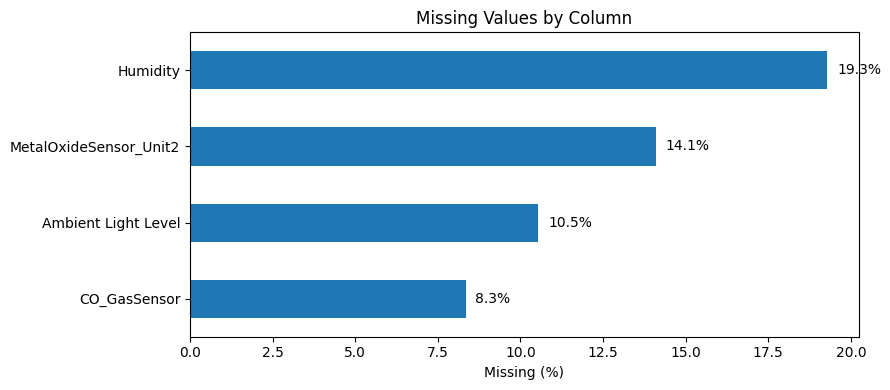

,Missing Count,Missing %
Humidity,1928,19.28
MetalOxideSensor_Unit2,1410,14.10
CO_GasSensor,834,8.34
Ambient Light Level,1054,10.54


In [ ]:
# Missing values
missing = df_raw.isnull().sum().rename("Missing Count")
missing_pct = (df_raw.isnull().mean() * 100).rename("Missing %").round(2)
missing_df = pd.concat([missing, missing_pct], axis=1).query("`Missing Count` > 0")

# plot bar graph
fig, ax = plt.subplots(figsize=(9, 4))
missing_df["Missing %"].sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values by Column")
for i, v in enumerate(missing_df["Missing %"].sort_values()):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()

# show in table
missing_df

* Humidity (19%), MetalOxideSensor_Unit2 (14%), CO_GasSensor (8%), and Ambient Light Level (11%)

* **Decision:** Use **median imputation** for numerics (robust to skew after outlier treatment) and **mode imputation** for categoricals

## 2b. Duplicate records

In [ ]:
# Duplicate rows
duplicates = df_raw.duplicated().sum()
print(f"Duplicate rows: {duplicates} ({duplicates/len(df_raw)*100:.2f}%)")

Duplicate rows: 171 (1.71%)


## 2c. Check inconsistent or dirty labels

In [ ]:
# Inconsistent / dirty category labels
for col in ["Activity Level", "HVAC Operation Mode", "Ambient Light Level", "Time of Day"]:
    uniq = sorted(df_raw[col].dropna().unique())
    print(f"\n{col} ({len(uniq)} unique):")
    for u in uniq:
        print(f"  {repr(u):35s}  count={df_raw[col].eq(u).sum()}")


Activity Level (6 unique):
  'High Activity'                      count=1095
  'Low Activity'                       count=5244
  'LowActivity'                        count=238
  'Low_Activity'                       count=285
  'Moderate Activity'                  count=2812
  'ModerateActivity'                   count=326

HVAC Operation Mode (23 unique):
  'COOLING_ACTIVE'                     count=112
  'Cooling_Active'                     count=64
  'Cooling_active'                     count=50
  'ECO_MODE'                           count=112
  'Eco_Mode'                           count=53
  'Eco_mode'                           count=56
  'HEATING_ACTIVE'                     count=98
  'Heating_Active'                     count=44
  'Heating_active'                     count=50
  'MAINTENANCE_MODE'                   count=106
  'Maintenance_Mode'                   count=49
  'Maintenance_mode'                   count=48
  'OFF'                                count=93
  'Off'       

* `Activity Level` and `HVAC Operation Mode` contained inconsistent casing and separators (e.g. "Low Activity", "LowActivity", "Low_Activity" all represent the same class). Standardised both columns to lowercase_underscore.

* `Ambient Light Level` and `Time of Day` were already consistent - no changes needed.

## 2d. Validate sensor ranges and abnormal values

In [ ]:
suspicious = (
    (df_raw['Temperature'] > 40) | (df_raw['Temperature'] < 18) |
    (df_raw['Humidity'] < 0)     | (df_raw['Humidity'] > 100)   |
    (df_raw['CO2_InfraredSensor'] < 0)
)
print(f"Rows with suspicious values: {suspicious.sum()} ({suspicious.sum()/len(df_raw)*100:.2f}%)")

Rows with suspicious values: 2452 (24.52%)


In [ ]:
# Quick outlier counts
temp_outliers = ((df_raw["Temperature"] < 18) | (df_raw["Temperature"] > 40)).sum()
humidity_outliers = ((df_raw["Humidity"] < 0) | (df_raw["Humidity"] > 100)).sum()
co2_negative = (df_raw["CO2_InfraredSensor"] < 0).sum()

outlier_summary = pd.DataFrame({
    "Feature":   ["Temperature", "Humidity", "CO2_InfraredSensor"],
    "Condition": ["< 18 or > 40 °C", "< 0 or > 100%", "< 0 ppm"],
    "Count":     [temp_outliers, humidity_outliers, co2_negative],
    "% of Data": [f"{temp_outliers/len(df_raw)*100:.2f}%",
                  f"{humidity_outliers/len(df_raw)*100:.2f}%",
                  f"{co2_negative/len(df_raw)*100:.2f}%"],
})

display(outlier_summary)

,Feature,Condition,Count,% of Data
0,Temperature,< 18 or > 40 °C,2041,20.41%
1,Humidity,< 0 or > 100%,414,4.14%
2,CO2_InfraredSensor,< 0 ppm,113,1.13%


* Temperature max = 307 °C (impossible for indoors)

* Humidity min/max = -49.9 %/198.9% (Normal range indoors/outdoors: 0-100%)

* CO2_InfraredSensor Min = -17.47 (CO2 concentration in air cannot be less than zero. Negative values typically arise from sensor issues)

For reference:

* Outdoor fresh air ~ 420 ppm
* Normal indoors ~ 600-1000 ppm
* Poor ventilation ~ 1000-2000 ppm

# 3. Target Variable Analysis — `Activity Level`

**Purpose:** Analyse the distribution of Activity Level, Check class imbalance, Understand activity category frequencies


In [ ]:
# Standardise labels (EDA view only, pipeline will do this formally)
df = df_raw.copy()

# Normalise Activity Level
df["Activity Level"] = (
    df["Activity Level"]
    .str.lower()
    .str.replace("_", "", regex=False)
    .str.strip()
    .replace({"lowactivity": "Low Activity",
              "moderateactivity": "Moderate Activity"})
    .str.title()
)

# Normalise HVAC
df["HVAC Operation Mode"] = (
    df["HVAC Operation Mode"]
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.strip()
)

print("Cleaned Activity Level distribution:")
vc_activity_level = df["Activity Level"].value_counts()
print(vc_activity_level)
print(f"\nClass imbalance ratio (Low:High) = {vc_activity_level['Low Activity']/vc_activity_level['High Activity']:.1f}:1")

Cleaned Activity Level distribution:
Activity Level
Low Activity         5767
Moderate Activity    3138
High Activity        1095
Name: count, dtype: int64

Class imbalance ratio (Low:High) = 5.3:1


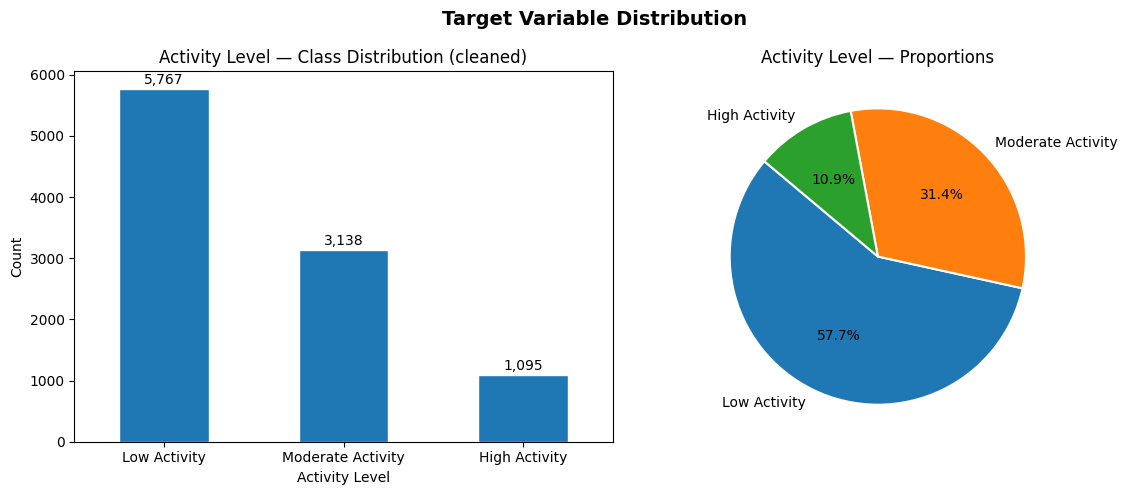

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot (no color specified)
vc_activity_level.plot(kind="bar", ax=axes[0], edgecolor="white", rot=0)
axes[0].set_title("Activity Level — Class Distribution (cleaned)")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width()/2, p.get_height()+30),
                     ha="center", va="bottom", fontsize=10)

# Pie chart (no color specified)
axes[1].pie(vc_activity_level.values, labels=vc_activity_level.index, autopct="%1.1f%%",
            startangle=140, wedgeprops={"edgecolor":"white","linewidth":1.5})
axes[1].set_title("Activity Level — Proportions")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

The dataset is imbalanced - a naive model predicting only `Low Activity` achieves ~58% accuracy, making accuracy a misleading metric

* Use weighted F1-score or macro F1 as primary evaluation metrics

* Apply class_weight='balanced' during training to compensate for the skew

# 4. Univariate Analysis

**Purpose:** Examine the distribution of each feature individually to identify skew and unusual patterns.


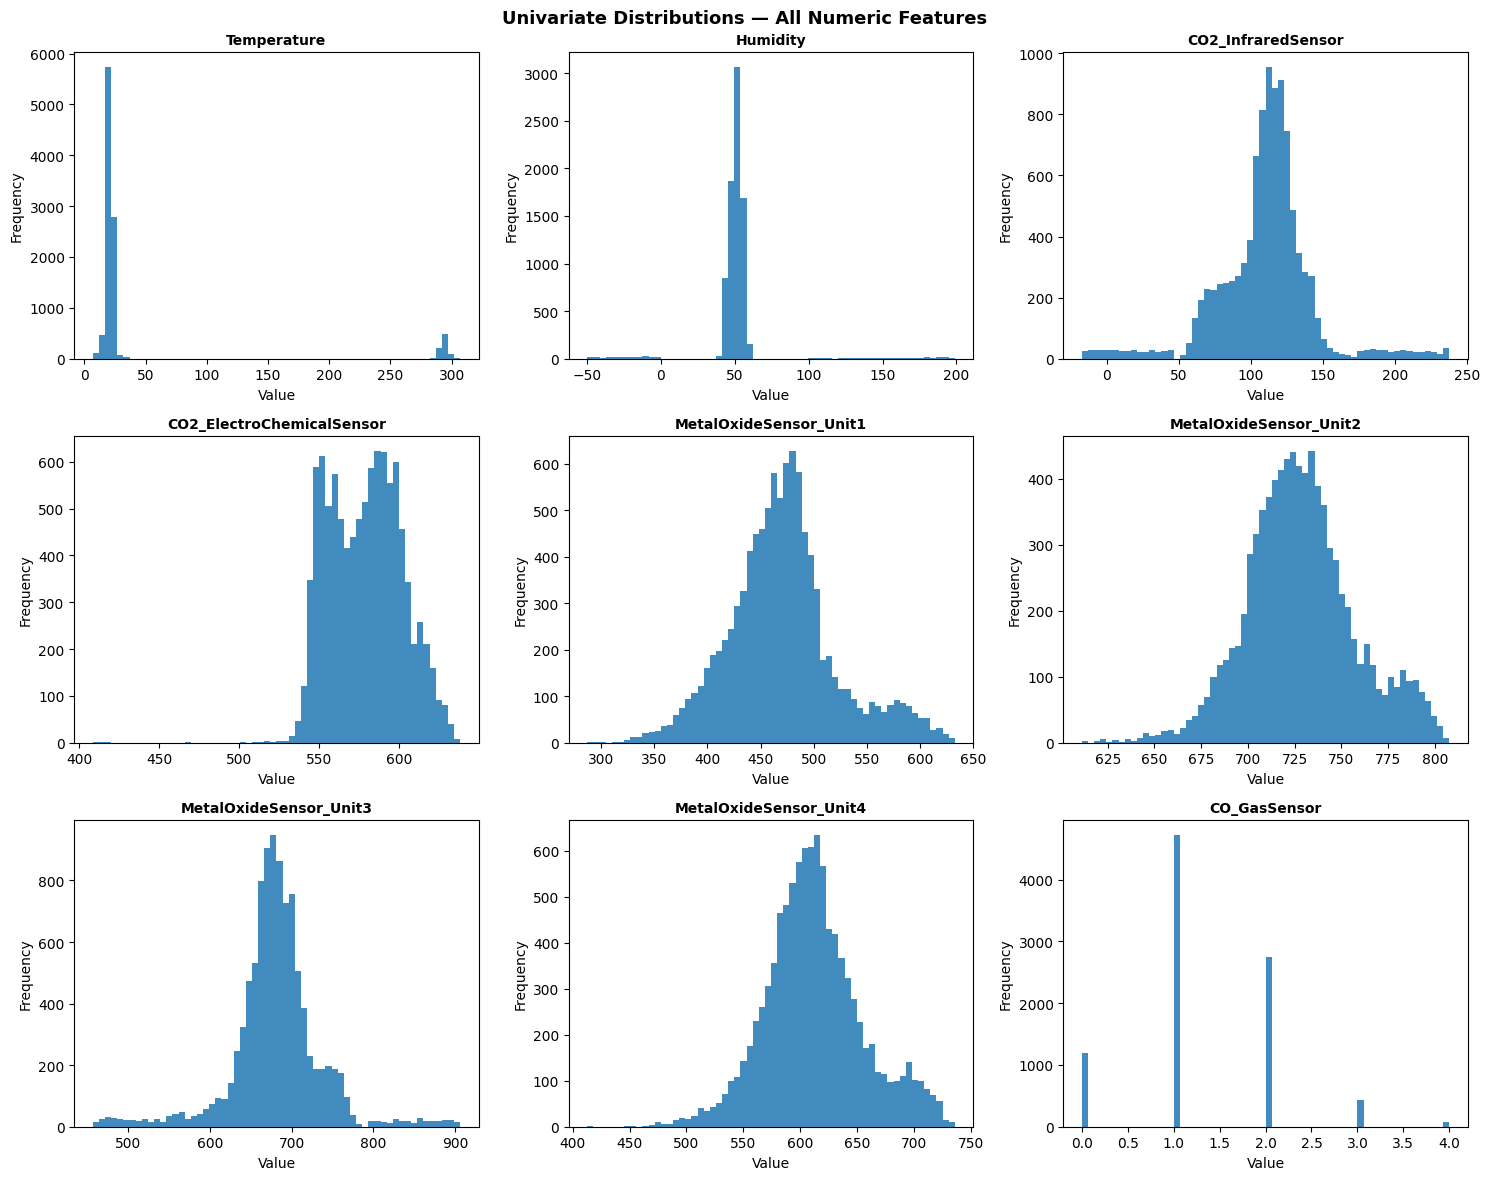

In [ ]:
numeric_cols = [
    "Temperature", "Humidity", "CO2_InfraredSensor", "CO2_ElectroChemicalSensor",
    "MetalOxideSensor_Unit1", "MetalOxideSensor_Unit2",
    "MetalOxideSensor_Unit3", "MetalOxideSensor_Unit4", "CO_GasSensor"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=60, alpha=0.85)
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Univariate Distributions — All Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations - Numeric Features:**

* **Temperature:** Bimodal distribution, normal range around 15-30°C, extreme outliers (up to 307°C) - erroneous sensor readings

* **Humidity:** concentrated 40-60%, negative values and >100% - sensor errors or calibration issues

* **CO2_Infraredsensors:** negative readings (physically impossible)

* **CO2_ElectrochemicalSensor:** realistic range (408-638 ppm)

* **MetalOxideSensors (Units 1-4):** different scales and distributions across their readings

* **CO _GasSensor:** Discrete values 0-4, Likely ordinal/categorical, not continuous




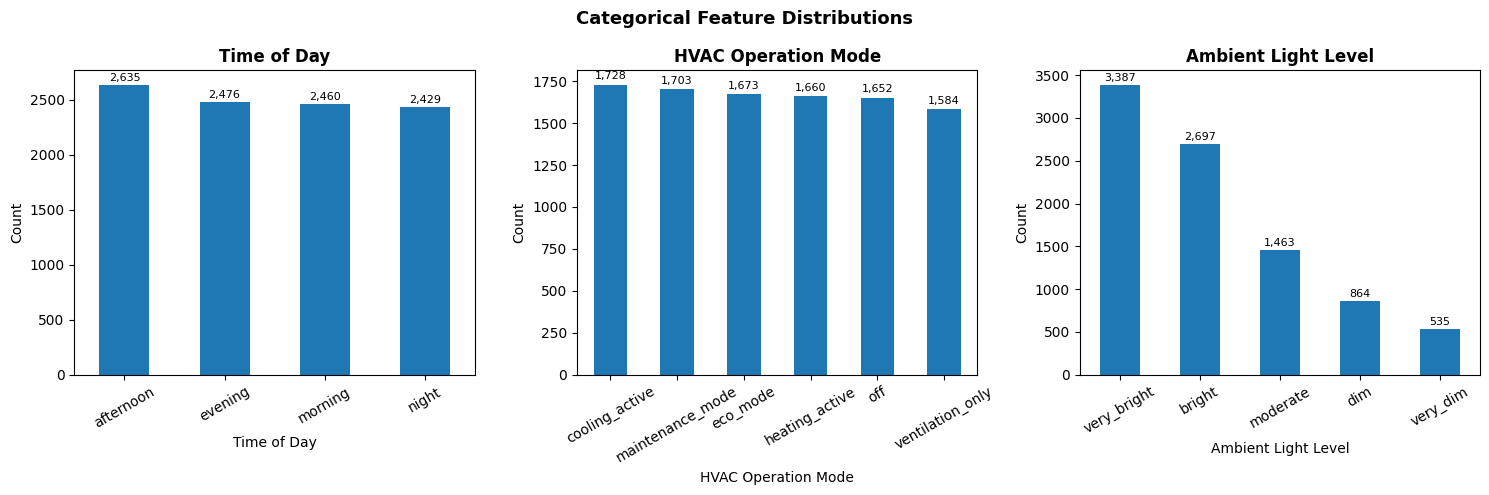

In [ ]:
# Categorical features
cat_cols = ["Time of Day", "HVAC Operation Mode", "Ambient Light Level"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts()
    vc.plot(kind="bar", ax=ax, rot=30)
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Count")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()+20),
                    ha="center", va="bottom", fontsize=8)

plt.suptitle("Categorical Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations - Categorical Features:**

* **Time of Day:** Relatively balanced distribution (afternoon 2635, evening 2476, morning 2460, night 2429)

* **HVAC Operation Mode:** After cleaning, 6 distinct modes with relatively balanced distribution (cooling_active ~1500, eco_mode ~1452, heating_active ~1468, maintenance_mode ~1500, off ~1456, ventilation_only ~1394)

* **Ambient Light Level:** Distribution skewed toward brighter conditions (very_bright 3387, bright 2697, moderate 1463, dim 864, very_dim 535)

# 5. Bivariate Analysis

**Purpose:** Explore relationships between features and Activity Level, Identify behavioural and environmental trends, Compare sensor patterns across activity categories


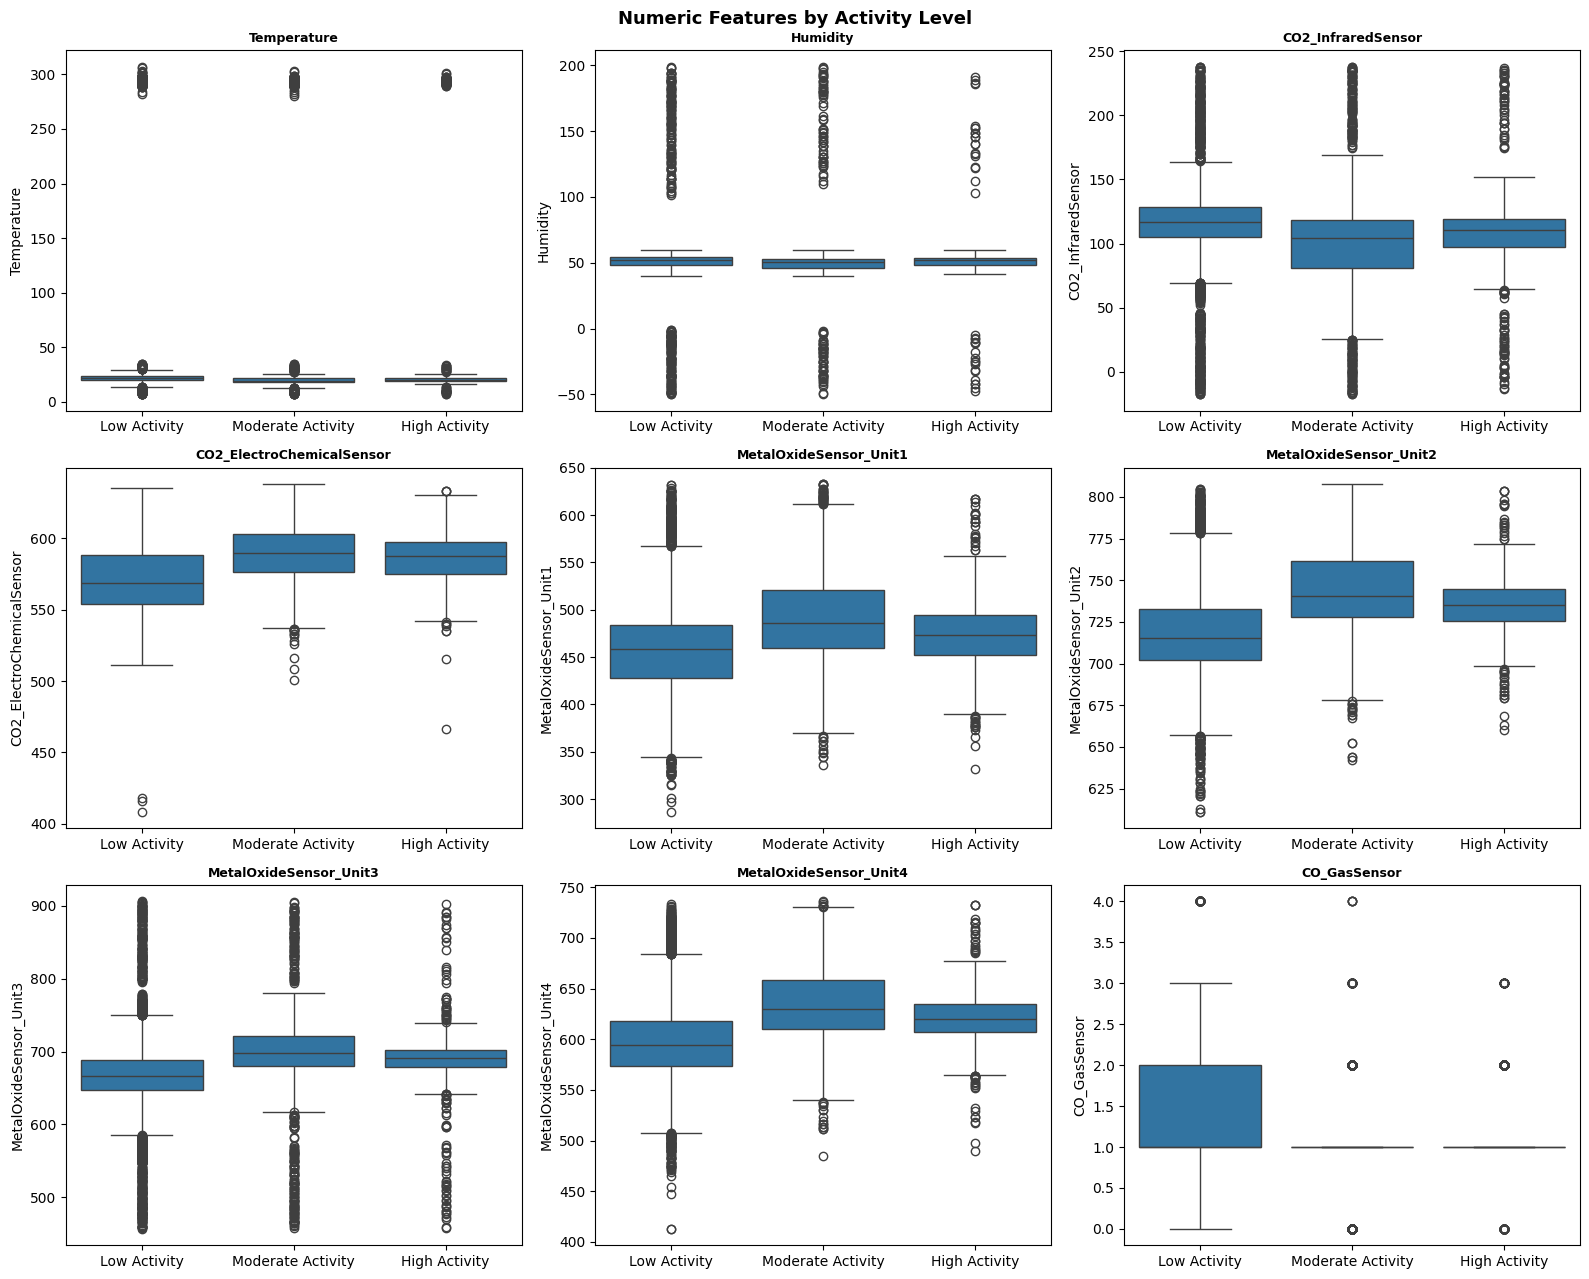

In [ ]:
# Box plots: numeric features vs Activity Level
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x="Activity Level", y=col, ax=axes[i],
                order=["Low Activity", "Moderate Activity", "High Activity"])
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("")

plt.suptitle("Numeric Features by Activity Level", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations - Numeric Features vs Activity Level:**

From the box plots:

* **Temperature:** Higher activity levels correlate with slightly higher temperatures (20-25°C range); low activity associated with lower temperatures

* **Humidity:** Moderate and High activity occur at slightly lower humidity levels (45-55%) compared to Low activity

* **CO2 sensors:** Higher activity shows elevated CO2 levels across both sensors, likely due to increased respiration rate during physical activity

* **Metal Oxide Sensors (all 4 units):** Show increasing values with higher activity levels - consistent pattern across all units

* **CO Gas Sensor:** Mostly values in 0-2 range, with little discernible correlation with activity level

**Statistical Testing: Temperature vs Activity Level**

We perform ANOVA testing to determine whether temperature distributions differ significantly across activity levels.

In [ ]:
from scipy.stats import f_oneway

low = df[df["Activity Level"] == "Low Activity"]["Temperature"].dropna()
moderate = df[df["Activity Level"] == "Moderate Activity"]["Temperature"].dropna()
high = df[df["Activity Level"] == "High Activity"]["Temperature"].dropna()

anova_result = f_oneway(low, moderate, high)

print(anova_result)

F_onewayResult(statistic=np.float64(1.1714481777624013), pvalue=np.float64(0.3099603388290233))


The ANOVA test produced a p-value greater than 0.05, suggesting that temperature distributions do not differ significantly across activity levels.

While temperature may still contribute predictive value when combined with other variables in machine learning models, temperature alone does not appear to strongly differentiate activity categories statistically.

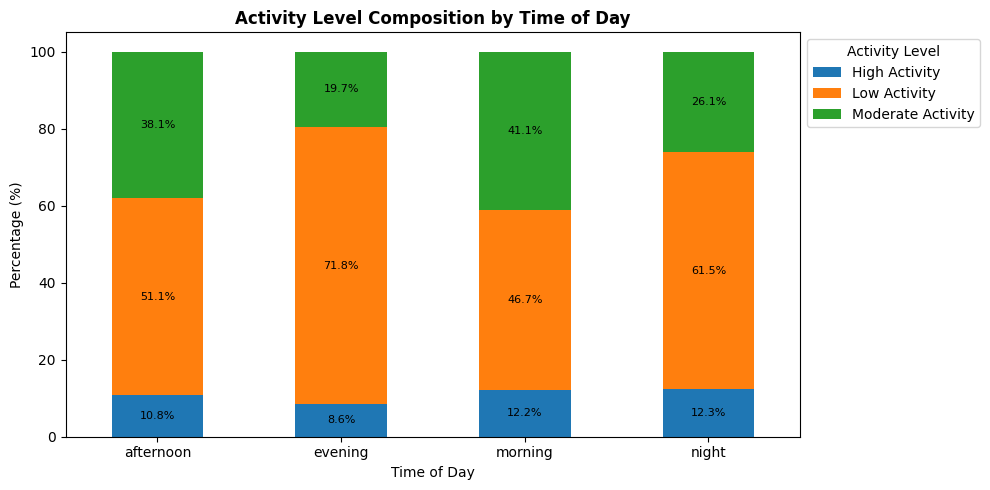

In [ ]:
# Activity Level by Time of Day
ct = pd.crosstab(df["Time of Day"], df["Activity Level"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

ax = ct_pct.plot(kind="bar", stacked=True, figsize=(10, 5), rot=0)
plt.title("Activity Level Composition by Time of Day", fontweight="bold")
plt.ylabel("Percentage (%)")
plt.legend(title="Activity Level", bbox_to_anchor=(1, 1))

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

**Observations - Time of Day vs Activity Level:**

* **Morning & Afternoon:** Active behavior (Moderate + High) is highest in the morning (53.3%) and afternoon (48.9%), with morning seeing the most purposeful movement (Moderate at 41.1%). Ideal for scheduling therapy and social events.

* **Evening:** Sedentary behavior peaks sharply in the evening, with Low activity jumping to 71.8% and High activity dropping to its lowest (8.6%). Reflects post-dinner relaxation and routines.

* **Night:** Low activity remains high at 61.5%. A minor baseline of High activity (12.3%) likely indicates occasional nighttime wandering or care interventions.

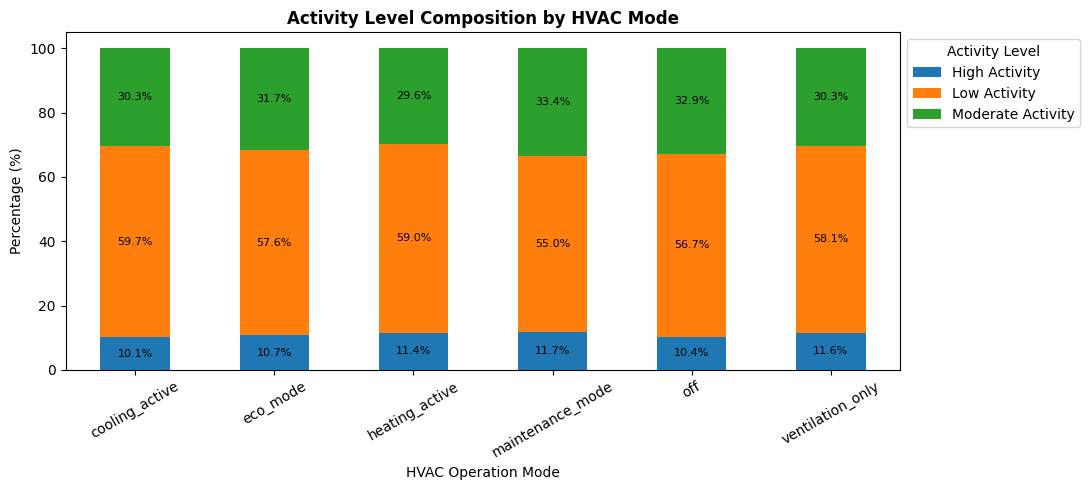

In [ ]:
# Activity Level by HVAC mode
ct2 = pd.crosstab(df["HVAC Operation Mode"], df["Activity Level"])
ct2_pct = ct2.div(ct2.sum(axis=1), axis=0) * 100

ax = ct2_pct.plot(kind="bar", stacked=True, figsize=(11, 5), rot=30)
plt.title("Activity Level Composition by HVAC Mode", fontweight="bold")
plt.ylabel("Percentage (%)")
plt.legend(title="Activity Level", bbox_to_anchor=(1,1))

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

**Observations - HVAC Mode vs Activity Level:**

- cooling_active has the lowest High Activity proportion (10.1%) (residents at rest)

- maintenance_mode has the Moderate/High Activity (33.4% + 11.7%)

**Statistical Testing: HVAC Mode vs Activity Level**

A chi-square test is used to determine whether HVAC operating mode is associated with activity level.

In [ ]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    df["HVAC Operation Mode"],
    df["Activity Level"]
)

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("P-value:", p)

Chi-square statistic: 14.006302525092453
P-value: 0.1727043242777708


The chi-square test produced a p-value greater than 0.05, indicating insufficient statistical evidence to conclude that HVAC operating mode and activity level are associated.

Although HVAC settings may still contribute useful information in machine learning models, the relationship was not statistically significant in this analysis.

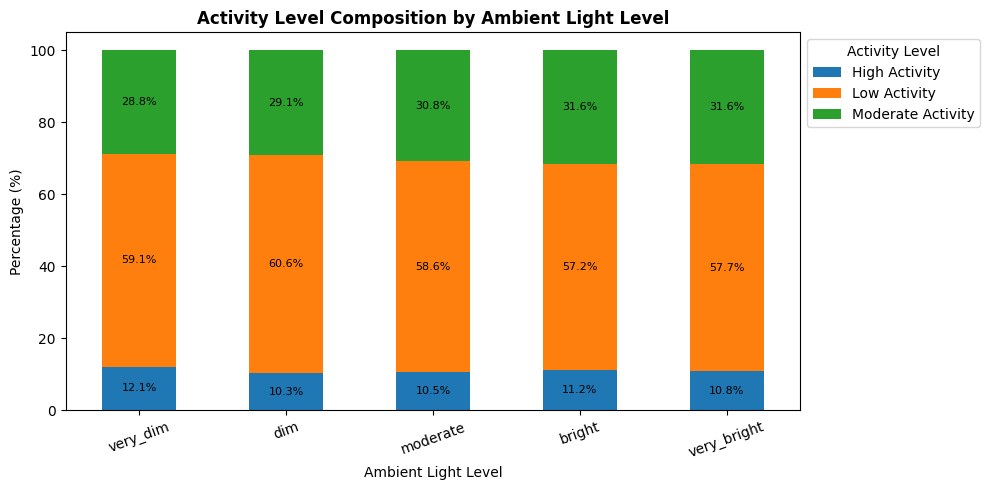

In [ ]:
# Ambient Light Level vs Activity Level
ct3 = pd.crosstab(df["Ambient Light Level"], df["Activity Level"])
ct3_pct = ct3.div(ct3.sum(axis=1), axis=0) * 100

order_light = ["very_dim","dim","moderate","bright","very_bright"]
ct3_pct = ct3_pct.reindex(order_light)

ax = ct3_pct.plot(kind="bar", stacked=True, figsize=(10,5), rot=20)
plt.title("Activity Level Composition by Ambient Light Level", fontweight="bold")
plt.ylabel("Percentage (%)")
plt.legend(title="Activity Level", bbox_to_anchor=(1,1))

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=8)

plt.tight_layout()
plt.show()

**Observations - Ambient Light Level vs Activity Level:**

- Very_bright and bright light levels correlate with higher activity levels (31.6% Moderate for both)

- Very_dim and dim light levels correlate with lower activity levels (59.1% and 60.6% Low respectively)

This matches expectation that physical activity increases during daylight hours

# 6. Correlation Analysis

**Purpose:** Understand linear relationships between numeric features and the target and between features themselves


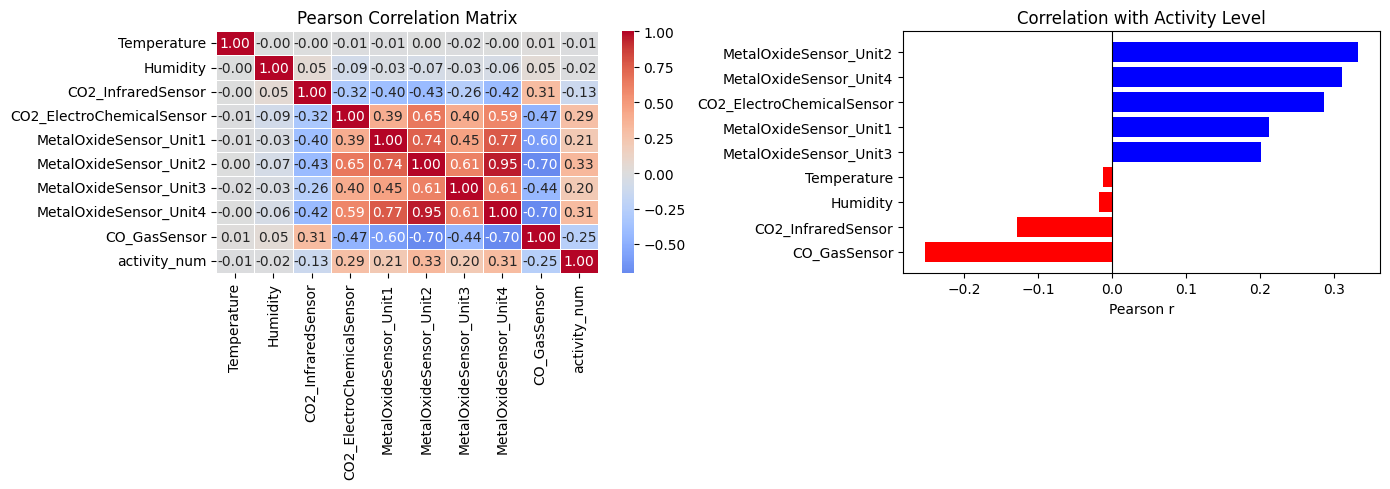

In [ ]:
df_enc = df.copy()
df_enc['activity_num'] = df_enc['Activity Level'].map(
    {'Low Activity': 0, 'Moderate Activity': 1, 'High Activity': 2})

corr_matrix = df_enc[numeric_cols + ['activity_num']].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], linewidths=0.4)
axes[0].set_title('Pearson Correlation Matrix')

# Bar chart of correlation with target
target_corr = corr_matrix['activity_num'].drop('activity_num').sort_values()
colors = ['red' if v < 0 else 'blue' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with Activity Level')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

**Key Correlation Findings:**

**Strong positive correlations (r > 0.7):**
- `CO2_InfraredSensor` and `CO2_ElectroChemicalSensor` are highly correlated with each other, as expected since both measure CO2 using different technologies. This introduces multicollinearity — models sensitive to it (e.g. Logistic Regression) may benefit from dropping one of the two.
- `MetalOxideSensor_Unit1`, `Unit3`, and `Unit4` are moderately correlated with each other, suggesting they respond to similar VOC sources.

**Correlation with target (Activity Level — encoded as ordinal):**
- `MetalOxideSensor_Unit2` (r ≈ 0.33) and `Unit4` (r ≈ 0.31) show the strongest individual correlations with activity level.
- All other features show weak correlations (r < 0.3), suggesting activity prediction requires interaction between multiple features — supporting the choice of ensemble models over linear ones.

**Implication for modelling:**
- Consider dropping `CO2_InfraredSensor` or `CO2_ElectroChemicalSensor` (keep one) to reduce redundancy.
- Do not rely on any single feature; tree-based ensemble models that capture feature interactions are better suited to this dataset.

In [ ]:
# high correlation more than 60
corr = df[numeric_cols].corr()
high_corr = [(c1, c2, corr.loc[c1, c2]) for c1 in numeric_cols for c2 in numeric_cols if c1 < c2 and abs(corr.loc[c1, c2]) > 0.6]
print(f"Highly correlated pairs (>0.6): {high_corr}")

Highly correlated pairs (>0.6): [('CO2_ElectroChemicalSensor', 'MetalOxideSensor_Unit2', np.float64(0.6525274693641403)), ('MetalOxideSensor_Unit1', 'MetalOxideSensor_Unit2', np.float64(0.7423080431211936)), ('MetalOxideSensor_Unit1', 'MetalOxideSensor_Unit4', np.float64(0.7714776579077616)), ('MetalOxideSensor_Unit2', 'MetalOxideSensor_Unit3', np.float64(0.6124749703404188)), ('MetalOxideSensor_Unit2', 'MetalOxideSensor_Unit4', np.float64(0.9495846902101415)), ('MetalOxideSensor_Unit3', 'MetalOxideSensor_Unit4', np.float64(0.6089598281254825)), ('CO_GasSensor', 'MetalOxideSensor_Unit1', np.float64(-0.6017641305459934)), ('CO_GasSensor', 'MetalOxideSensor_Unit2', np.float64(-0.7034956607546352)), ('CO_GasSensor', 'MetalOxideSensor_Unit4', np.float64(-0.702438527146233))]


In [ ]:
df_high_corr = pd.DataFrame(high_corr, columns=['Feature 1', 'Feature 2', 'Correlation'])
display(df_high_corr)

,Feature 1,Feature 2,Correlation
0,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit2,0.652527
1,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,0.742308
2,MetalOxideSensor_Unit1,MetalOxideSensor_Unit4,0.771478
3,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,0.612475
4,MetalOxideSensor_Unit2,MetalOxideSensor_Unit4,0.949585
5,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,0.608960
6,CO_GasSensor,MetalOxideSensor_Unit1,-0.601764
7,CO_GasSensor,MetalOxideSensor_Unit2,-0.703496
8,CO_GasSensor,MetalOxideSensor_Unit4,-0.702439


In [ ]:
target_corr.sort_values(ascending=False).to_frame('Correlation with Activity Level')

,Correlation with Activity Level
MetalOxideSensor_Unit2,0.332823
MetalOxideSensor_Unit4,0.310608
CO2_ElectroChemicalSensor,0.286469
MetalOxideSensor_Unit1,0.212127
MetalOxideSensor_Unit3,0.201715
Temperature,-0.012518
Humidity,-0.016786
CO2_InfraredSensor,-0.128360
CO_GasSensor,-0.252814


**Feature-to-feature correlations:**

- MOS Unit2 and Unit4 are nearly identical (r = 0.95) - strong redundancy, consider dropping one

- MOS Unit1 - Unit2 (0.74) and Unit1 - Unit4 (0.77) — moderate redundancy across MOS group

- CO2 Infrared - Electrochemical = -0.32 — weakly negatively correlated, not redundant; both carry independent information and should be kept

- CO_GasSensor is strongly negatively correlated with MOS sensors (-0.60 to -0.70) — as gas sensor VOC readings rise, CO drops

- Temperature and Humidity are near-zero correlated with all other features — largely independent environmental readings

**Key takeaways:**

- MOS Unit2 and Unit4 are the strongest predictors and nearly identical — dropping Unit4 is worth experimenting with

- Both CO2 sensors should be retained as they are independent and carry different signals

- CO_GasSensor inverse relationship suggests higher activity correlates with better ventilation, reducing CO buildup

- Temperature and Humidity contribute minimal predictive signal on their own

# 7. Session-Level Analysis

**Purpose:** Analyse activity patterns across different times of day, Investigate session-level behavioural trends, Examine environmental changes over monitoring sessions


In [ ]:
session_stats = df.groupby("Session ID").agg(
    rows=("Activity Level","count"),
    dominant_activity=("Activity Level", lambda x: x.mode()[0]),
    n_activities=("Activity Level","nunique"),
    mean_temp=("Temperature","mean"),
    mean_co2=("CO2_InfraredSensor","mean")
).reset_index()

print(f"Total sessions: {len(session_stats)}")
print(f"Rows per session: mean={session_stats['rows'].mean():.0f}, "
      f"min={session_stats['rows'].min()}, max={session_stats['rows'].max()}")
print("\nActivity diversity per session:")
print(session_stats["n_activities"].value_counts())

Total sessions: 38
Rows per session: mean=263, min=56, max=388

Activity diversity per session:
n_activities
3    38
Name: count, dtype: int64


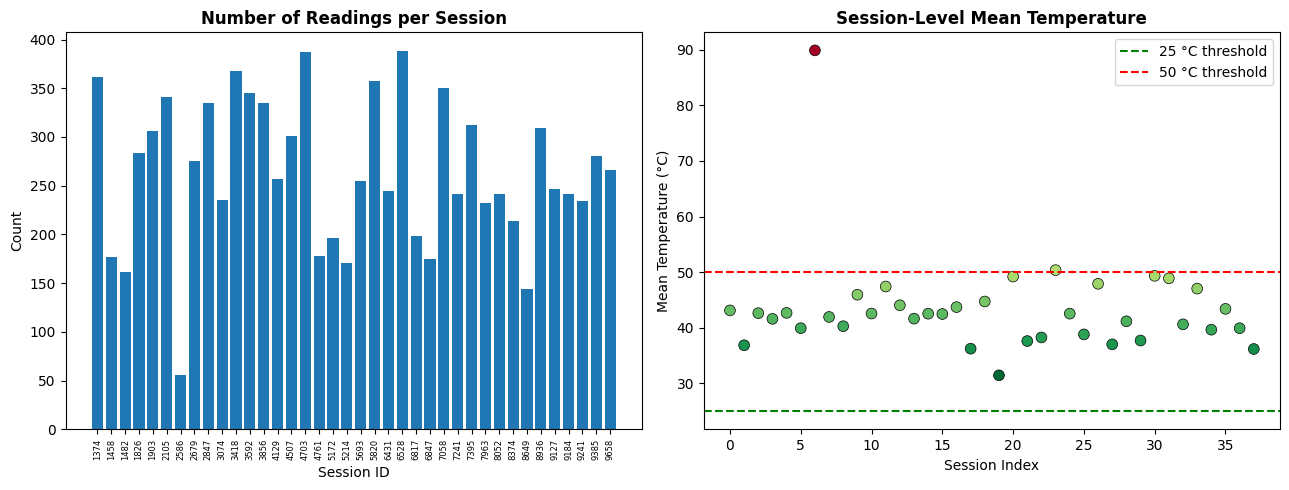

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Rows per session
axes[0].bar(session_stats["Session ID"].astype(str), session_stats["rows"])
axes[0].set_title("Number of Readings per Session", fontweight="bold")
axes[0].set_xlabel("Session ID")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=90, labelsize=6)

# Session-level mean Temperature (shows outlier sessions)
axes[1].scatter(range(len(session_stats)), session_stats["mean_temp"],
                c=session_stats["mean_temp"], cmap="RdYlGn_r", s=60, edgecolors="k", linewidths=0.5)
axes[1].axhline(25, color="green", linestyle="--", label="25 °C threshold")
axes[1].axhline(50, color="red", linestyle="--", label="50 °C threshold")
axes[1].set_title("Session-Level Mean Temperature", fontweight="bold")
axes[1].set_xlabel("Session Index")
axes[1].set_ylabel("Mean Temperature (°C)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
sessions_temp_morethan_40 = session_stats[(session_stats['mean_temp'] >= 40)]
display(sessions_temp_morethan_40[['Session ID', 'mean_temp']])

,Session ID,mean_temp
0,1374,43.132017
2,1482,42.640343
3,1826,41.618141
4,1903,42.688600
6,2586,89.869677
7,2679,41.956529
8,2847,40.294845
9,3074,45.956929
10,3418,42.571895
11,3592,47.426840


Session 2586 is a contaminated session (mean temp 89.87°C) - its rows should be treated as outliers.

In [ ]:
# Check Session 2586 for unrealistic CO2 and humidity values
suspect_session = 2586
session_data = df[df["Session ID"] == suspect_session]

print(f"Session {suspect_session} Analysis (mean temp = 89.9°C)")
print("-" * 40)

# CO2 ElectroChemical (reliable range: 400-650 ppm)
co2_mean = session_data["CO2_ElectroChemicalSensor"].mean()
print(f"CO2_ElectroChemicalSensor mean: {co2_mean:.1f} ppm {'(unrealistic)' if co2_mean < 400 or co2_mean > 650 else '(normal)'}")

# Humidity (valid range: 0-100%)
humidity_mean = session_data["Humidity"].mean()
print(f"Humidity mean: {humidity_mean:.1f}% {'(invalid)' if humidity_mean < 0 or humidity_mean > 100 else '(valid)'}")

# Activity distribution
print("\nActivity Level distribution:")
print(session_data["Activity Level"].value_counts())

Session 2586 Analysis (mean temp = 89.9°C)
----------------------------------------
CO2_ElectroChemicalSensor mean: 561.2 ppm (normal)
Humidity mean: 47.2% (valid)

Activity Level distribution:
Activity Level
Moderate Activity    26
Low Activity         25
High Activity         5
Name: count, dtype: int64


Only temperature is corrupted (89.9°C impossible for indoors). CO2 and humidity are normal. Still recommend excluding the entire session as a conservative data quality measure.

Beyond calculating missing percentages, we also investigate whether missing values occur randomly or cluster around specific sessions or activity levels.

This helps identify:
- sensor failures
- contaminated sessions
- systematic data collection issues

Understanding missingness patterns allows us to choose more reliable imputation strategies.

In [ ]:
missing_by_session = (
    df.groupby("Session ID")
      .apply(lambda x: x.isnull().sum().sum())
      .sort_values(ascending=False)
)

missing_by_session.head(10)

/tmp/ipykernel_954/2071240874.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().sum().sum())


,0
Session ID,
4703,217
5820,200
6528,189
2105,188
3856,181
7395,180
3418,176
3592,175
1374,173


In [ ]:
missing_by_activity = (
    df.groupby("Activity Level")
      .apply(lambda x: x.isnull().mean() * 100)
)

missing_by_activity

/tmp/ipykernel_954/2104684004.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isnull().mean() * 100)


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
Activity Level,,,,,,,,,,,,,,
High Activity,0.0,0.0,17.716895,0.0,0.0,0.0,14.429224,0.0,0.0,8.219178,0.0,0.0,10.958904,0.0
Low Activity,0.0,0.0,19.472863,0.0,0.0,0.0,14.045431,0.0,0.0,8.531299,0.0,0.0,9.918502,0.0
Moderate Activity,0.0,0.0,19.471001,0.0,0.0,0.0,14.085405,0.0,0.0,8.030593,0.0,0.0,11.536010,0.0


# 8. Outlier Detection

**Purpose:** Quantify the extent of outliers and physically impossible values. This informs the data-cleaning strategy in the ML pipeline.


In [ ]:
# IQR-based outlier counting per numeric column
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (series < lo) | (series > hi)
    return mask.sum(), lo, hi

print(f"{'Column':<35} {'IQR Outliers':>14} {'Lower':>10} {'Upper':>10}")
print("-"*73)
for col in numeric_cols:
    n, lo, hi = iqr_outliers(df[col].dropna())
    pct = n / df[col].dropna().shape[0] * 100
    print(f"{col:<35} {n:>6} ({pct:4.1f}%)  {lo:>9.2f}  {hi:>9.2f}")

Column                                IQR Outliers      Lower      Upper
-------------------------------------------------------------------------
Temperature                            994 ( 9.9%)      12.59      29.52
Humidity                               414 ( 5.1%)      38.39      63.11
CO2_InfraredSensor                     805 ( 8.1%)      54.84     166.36
CO2_ElectroChemicalSensor                5 ( 0.1%)     505.03     649.89
MetalOxideSensor_Unit1                 609 ( 6.1%)     357.93     576.87
MetalOxideSensor_Unit2                 160 ( 1.9%)     656.83     797.71
MetalOxideSensor_Unit3                 820 ( 8.2%)     591.02     771.03
MetalOxideSensor_Unit4                 293 ( 2.9%)     509.76     711.76
CO_GasSensor                            75 ( 0.8%)      -0.50       3.50


In [ ]:
# Domain-knowledge outlier thresholds
domain_checks = {
    "Temperature": (18, 40),     # Indoor residential: 18–40 °C
    "Humidity":    (0, 100),    # Physical limits
}

print("Domain-knowledge outlier counts:")
for col, (lo, hi) in domain_checks.items():
    n = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"  {col}: {n} rows outside [{lo}, {hi}]")


Domain-knowledge outlier counts:
  Temperature: 2041 rows outside [18, 40]
  Humidity: 414 rows outside [0, 100]


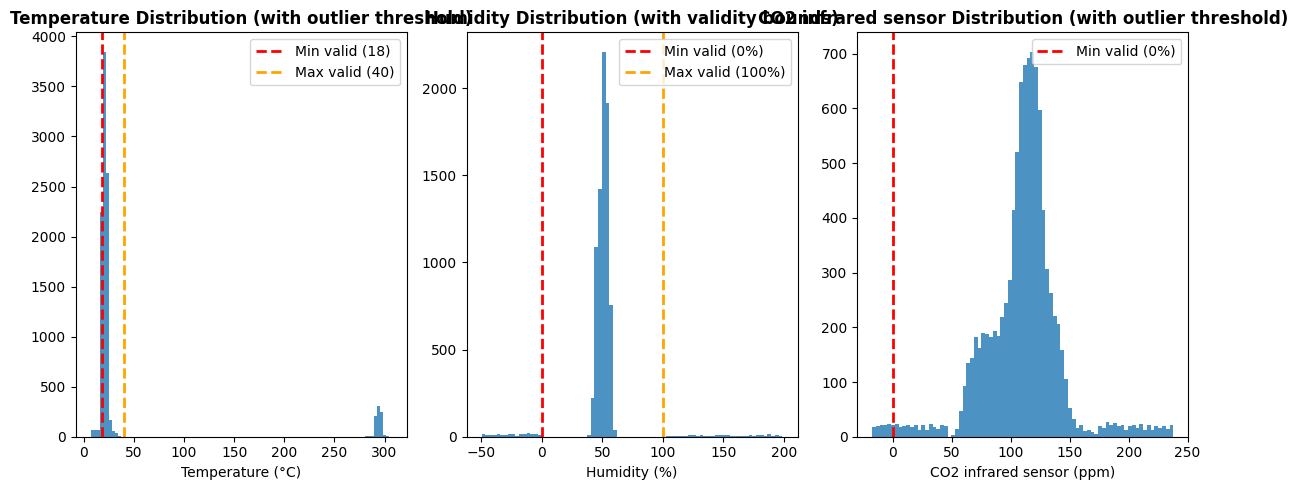

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# Temperature — log scale to show outliers
axes[0].hist(df["Temperature"], bins=100, alpha=0.8)
axes[0].axvline(18, color="red", linestyle="--", linewidth=2, label="Min valid (18)")
axes[0].axvline(40, color="orange", linestyle="--", linewidth=2, label="Max valid (40)")
axes[0].set_title("Temperature Distribution (with outlier threshold)", fontweight="bold")
axes[0].set_xlabel("Temperature (°C)")
axes[0].legend()

# Humidity — show invalid values
axes[1].hist(df["Humidity"].dropna(), bins=80, alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", linewidth=2, label="Min valid (0%)")
axes[1].axvline(100, color="orange", linestyle="--", linewidth=2, label="Max valid (100%)")
axes[1].set_title("Humidity Distribution (with validity bounds)", fontweight="bold")
axes[1].set_xlabel("Humidity (%)")
axes[1].legend()

# CO2 infrared sensor — show invalid values
axes[2].hist(df["CO2_InfraredSensor"].dropna(), bins=80, alpha=0.8)
axes[2].axvline(0, color="red", linestyle="--", linewidth=2, label="Min valid (0%)")
axes[2].set_title("CO2 infrared sensor Distribution (with outlier threshold)", fontweight="bold")
axes[2].set_xlabel("CO2 infrared sensor (ppm)")
axes[2].legend()

plt.tight_layout()
plt.show()


**Outlier Handling Decisions**

| Feature | Issue Found | Decision | Justification |
|---|---|---|---|
| Temperature | Values ~292°C (physically impossible indoors) | Cap at 40°C (realistic indoor max) OR flag and remove rows | A sensor reading of 292°C cannot reflect real indoor conditions; retaining it would distort model training |
| CO2_InfraredSensor | Extreme high values (e.g. >5000 ppm) | Cap using IQR upper fence (Q3 + 1.5xIQR) | CO2 above 5000 ppm indoors is unrealistic without equipment failure; IQR capping is conservative |
| MetalOxideSensor units | Some extreme highs | Retain but flag | MOS readings can legitimately spike; removing may lose signal relevant to High Activity |
| CO_GasSensor | Zeroes and near-zeroes mixed with NaN | Treat 0 as valid (sensor baseline) | CO sensors commonly read near-zero in safe environments |

**Assumption:** Rows where Temperature > 100°C are treated as contaminated sensor readings and will be removed/capped in the ML pipeline preprocessing step.

# 9. Feature Engineering

**Purpose:** Identify useful derived features, Explore feature transformations and encoding strategies, Assess feature importance candidates for predictive modelling


In [ ]:
# Proposed Feature 1: CO2 Sensor Disagreement
# If the two CO2 sensors disagree, it may indicate sensor fault or environmental anomaly
df["CO2_Disagreement"] = (df["CO2_InfraredSensor"] - df["CO2_ElectroChemicalSensor"]).abs()

# Proposed Feature 2: Mean MOS Reading
# Average of all 4 MOS units (reduces noise, handles partial missing)
df["MOS_Mean"] = df[["MetalOxideSensor_Unit1","MetalOxideSensor_Unit2",
                      "MetalOxideSensor_Unit3","MetalOxideSensor_Unit4"]].mean(axis=1)

# Proposed Feature 3: Ambient Light Ordinal
light_map = {"very_dim":1, "dim":2, "moderate":3, "bright":4, "very_bright":5}
df["Ambient_Light_Ordinal"] = df["Ambient Light Level"].map(light_map)

# Proposed Feature 4: Is_Night flag
df["Is_Night"] = (df["Time of Day"] == "night").astype(int)

# Show correlations of engineered features with MOS_Mean
print("Correlation of MOS_Mean with Activity Level proxy:")
df["Activity_Encoded"] = df["Activity Level"].map({"Low Activity":0,"Moderate Activity":1,"High Activity":2})
for feat in ["CO2_Disagreement","MOS_Mean","Ambient_Light_Ordinal","Is_Night"]:
    corr_val = df[[feat, "Activity_Encoded"]].dropna().corr().iloc[0,1]
    print(f"  {feat}: r = {corr_val:.4f}")


Correlation of MOS_Mean with Activity Level proxy:
  CO2_Disagreement: r = 0.2337
  MOS_Mean: r = 0.2757
  Ambient_Light_Ordinal: r = 0.0101
  Is_Night: r = -0.0209


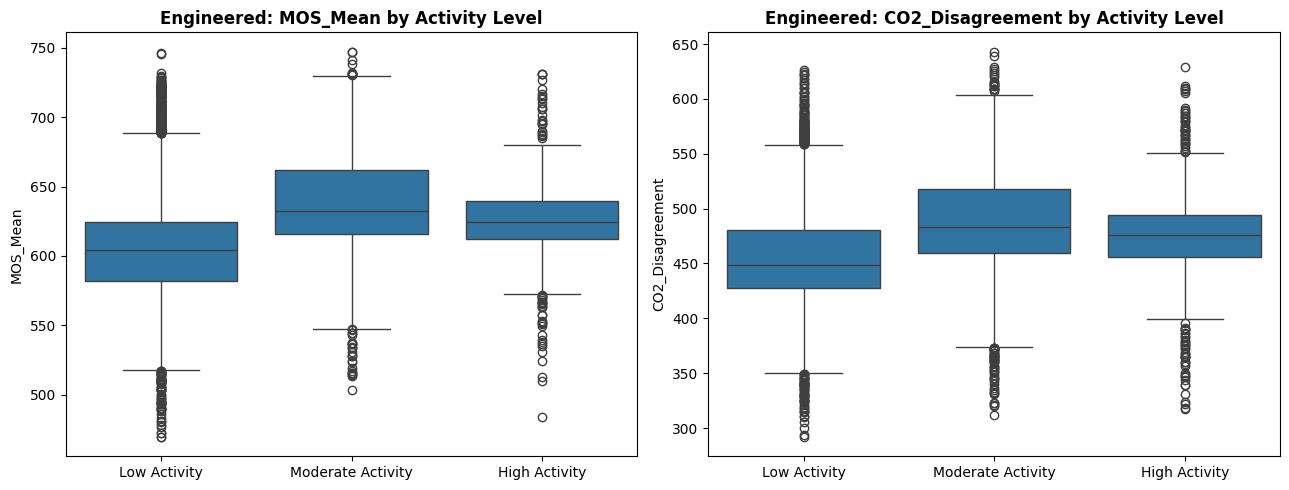

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# MOS_Mean by activity
sns.boxplot(data=df, x="Activity Level", y="MOS_Mean",
            order=["Low Activity","Moderate Activity","High Activity"],
            ax=axes[0])
axes[0].set_title("Engineered: MOS_Mean by Activity Level", fontweight="bold")
axes[0].set_xlabel("")

# CO2 Disagreement by activity
sns.boxplot(data=df, x="Activity Level", y="CO2_Disagreement",
            order=["Low Activity","Moderate Activity","High Activity"],
            ax=axes[1])
axes[1].set_title("Engineered: CO2_Disagreement by Activity Level", fontweight="bold")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


**Engineered Feature Justifications:**

| Feature | Rationale | Expected Benefit |
|---|---|---|
| **CO2_Disagreement** | Two different CO2 sensor technologies should agree. Large disagreement may indicate sensor drift, environmental anomaly, or high activity causing rapid CO2 flux | May capture unusual indoor air dynamics |
| **MOS_Mean** | Averaging 4 MOS units reduces individual sensor noise and handles missing values in Unit2 more gracefully | More robust VOC signal |
| **Ambient_Light_Ordinal** | Light level has a clear natural order (very dim → very bright). Ordinal encoding preserves this order for linear models | Better linear separability |
| **Is_Night** | Night is strongly associated with low activity (sleeping) — a binary flag makes this explicit | Simpler feature for tree splits |

- MOS_Mean (r = 0.28) performs slightly worse than the best individual units (Unit2: 0.33, Unit4: 0.31), suggesting averaging dilutes the stronger signal from Unit2/Unit4. Consider keeping Unit2 alone rather than aggregating all four

# 10. Summary of Key Findings & Recommendations

The EDA identified several important data quality issues, including inconsistent categorical labels, missing values, unrealistic sensor readings, and potentially contaminated sessions. Appropriate preprocessing strategies such as label standardisation, imputation, and outlier handling were therefore considered to improve overall data reliability.

Feature analysis showed that individual variables generally exhibit weak-to-moderate relationships with activity level, suggesting that activity prediction likely depends on interactions between multiple environmental signals rather than any single feature alone.

**Recommended Models for Task 2:**

| Model | Justification |
|---|---|
| **Random Forest** | Handles nonlinear relationships and feature interactions well; robust to outliers; provides built-in feature importance scores directly relevant to this task |
| **Gradient Boosting (XGBoost / LightGBM)** | Strong performance on tabular data with class imbalance; boosting corrects misclassified minority classes (High Activity) iteratively |
| **Logistic Regression (Baseline)** | Simple, interpretable baseline to compare against; will reveal whether the problem is linearly separable; fast to train |

**Primary evaluation metric:** Macro F1-score, to ensure equal weight is given to all three activity classes including the minority High Activity class. Accuracy alone would be misleading given class imbalance.

*~ End of EDA ~*